In [1]:
import warnings
warnings.filterwarnings('ignore')

(Tutorial_Get_hydrophobic_interactions)=
# get_hydrophobic_interactions

*Calculating sparse proximity between chemically typed hydrophobic atoms.*

The experimental `atom_pair_distance` method uses profile `smarts_hydrophobic_atoms`, reproducing the ProLIF 2.2.2 Hydrophobic/Distance core. It returns an independent analysis with source indices and evaluated coverage. A typed proximity observation is not an interaction energy or a measurement of solvent-mediated attraction.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

See {func}`molsysmt.interactions.hydrophobic.get_hydrophobic_interactions` for arguments, returned data and explicit failures.
:::

## Basic usage

Let's show how this function works with three controlled structures of two aliphatic fragments. Only their central carbon atoms match this profile. The middle frame lies outside the 0.45 nm inclusive cutoff. These synthetic coordinates demonstrate the criterion, not an optimized binding pose.

In [2]:
import molsysmt as msm

In [3]:
from rdkit import Chem
import numpy as np
from molsysmt import pyunitwizard as puw

molsys = msm.convert(Chem.MolFromSmiles('CCC.CCC'), to_form='molsysmt.MolSys')
xyz = np.array([[0,0,0], [.15,0,0], [.30,0,0], [0,.30,0], [.15,.30,0], [.30,.30,0]])
coordinates = np.repeat(xyz[None], 3, axis=0)
coordinates[1, 3:] += [0, 1., 0]
molsys.structures.append(coordinates=puw.quantity(coordinates, 'nm'))

In [4]:
analysis = msm.interactions.hydrophobic.get_hydrophobic_interactions(molsys, pbc=False)
print(analysis.participant_atoms)
print(analysis.participant_roles)
print(analysis.occurrence_structures)
print('Evaluated empty frame:', analysis.query(structure_indices=[1]).n_interactions)

[1 4]
('hydrophobic_1', 'hydrophobic_2')
[0 2]
Evaluated empty frame: 0


## Interpreting unordered pairs

Distinct atom pairs appear once, in ascending source-index order. Roles `hydrophobic_1` and `hydrophobic_2` describe that canonical order; they do not identify ligand and protein sides. Self observations are excluded, while distinct coincident atoms can have zero distance. No covalent or intramolecular filter is silently added to the reference core. For a ligand/environment analysis, explicitly choose disjoint sets and use `between`.

In [5]:
interface = msm.interactions.hydrophobic.get_hydrophobic_interactions(
    molsys, selection=[3, 4, 5], selection_2=[0, 1, 2], selection_mode='between', pbc=False)
assert interface.participant_atoms.tolist() == [1, 4]
print(interface.parameters['pair_identity'])
print(interface.parameters['covalent_exclusion'])

distinct_unordered_source_atom_indices
none


## Selecting frames and participating atoms

`internal` requires both sites in one selection, `incident` either site, and `between` one in each disjoint selection. Repeated structure indices are evaluated once; the result preserves original frame indices, including evaluated frames without occurrences. Queries do not rerun the detector.

In [6]:
for mode, first, second in [('internal', [4], None), ('incident', [4], None), ('between', [4], [1])]:
    scoped = msm.interactions.hydrophobic.get_hydrophobic_interactions(
        molsys, selection=first, selection_2=second, selection_mode=mode,
        structure_indices=[2, 0, 2], pbc=False)
    print(mode, scoped.n_interactions, scoped.evaluated_structure_indices)
print(analysis.query(atom_indices=[4], mode='cross').n_interactions)

internal 0 [0 2]


incident 2 [0 2]


between 2 [0 2]
2


## Measuring distance over structures

Every evaluated frame can contain a different count, including zero. The plot shows occurrence distances and coverage separately, without representing missing observations as zero distance.

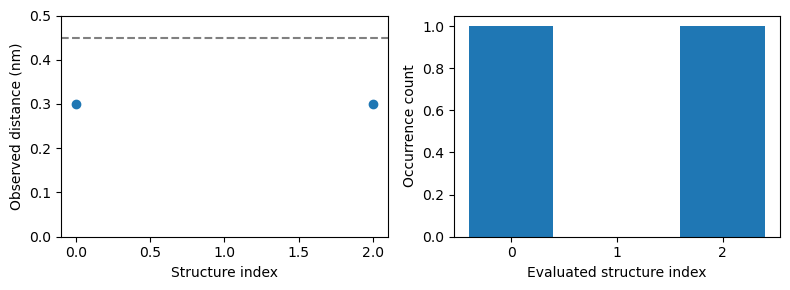

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].scatter(analysis.occurrence_structures, analysis.measurements['distance'])
axes[0].axhline(.45, color='gray', linestyle='--')
axes[0].set(xlabel='Structure index', ylabel='Observed distance (nm)', ylim=(0, .5))
axes[1].bar(analysis.evaluated_structure_indices, [analysis.query(structure_indices=[i]).n_interactions for i in analysis.evaluated_structure_indices])
axes[1].set(xlabel='Evaluated structure index', ylabel='Occurrence count', xticks=[0, 1, 2])
fig.tight_layout()

## Choosing units and typed output

Thresholds are scalar lengths with units. Output columns declare `nm` independently of a non-default unit policy. Typed output retains the whole analysis, not one dictionary per occurrence. No numeric tolerance expands the cutoff; floating-point conversions can affect an exact boundary.

In [8]:
with puw.context(standard_units=['angstrom', 'degrees', 'ps', 'e']):
    typed = msm.interactions.hydrophobic.get_hydrophobic_interactions(
        molsys, distance_threshold='4.5 angstroms', pbc=False, output_type='molsysmt.InteractionsDict')
restored = msm.convert(typed, to_form='molsysmt.Interactions')
assert restored.n_interactions == analysis.n_interactions
print(restored.measure_units)

{'distance': 'nm'}


## Reconstructing periodic images

MIC is anchored on the lower atom index, independent of which selected side produced the neighbor search. With box vectors as rows, add `image_vector @ box` to each participating coordinate. The stored image reconstructs the observed distance; it is not an enumeration of every possible periodic contact.

In [9]:
periodic = msm.extract(molsys, structure_indices=[0])
box = np.eye(3)
lattice = np.zeros((6, 3), dtype=int)
lattice[4] = [1, -1, 0]
periodic.structures.coordinates = puw.quantity(coordinates[:1] + lattice @ box, 'nm')
periodic.structures.box = puw.quantity(box[None], 'nm')
images = msm.interactions.hydrophobic.get_hydrophobic_interactions(
    periodic, selection=[4], selection_2=[1], selection_mode='between')
observed = puw.get_value(periodic.structures.coordinates, to_unit='nm')[0, images.participant_atoms] + images.image_vectors @ box
print(images.image_vectors)
print('Observed distance:', np.linalg.norm(observed[1] - observed[0]))

[[ 0  0  0]
 [-1  1  0]]
Observed distance: 0.30000000000000004


## Inspecting peptide chemistry before geometry

The general chemical tool can identify candidate sites in a peptide with aliphatic and aromatic sidechains. This step supplies atomic participants, not a residue hydrophobicity score or a proposed peptide/ligand pose. Input structures need declared chemical assignments before this detector can use their coordinates.

In [10]:
features = msm.physchem.get_hydrophobic_sites(Chem.MolFromSequence('FLF'))
print(features['hydrophobic_atom_indices'])

[ 4  5  6  7  8  9 10 15 16 23 24 25 26 27 28 29]


## Calculating from files and recording results

Attachment is explicit and named. Eligible native/H5MSM inputs stream projected coordinates with `heavy_mode="auto"` or `"force"`; full chemistry and accepted sparse output remain resident. Rich file selections may need bounded eager loading. Match, candidate and resident-result limits raise explicitly; these numerical estimates do not cap process RSS.

In [11]:
from pathlib import Path
from tempfile import TemporaryDirectory
with TemporaryDirectory() as directory:
    path = str(Path(directory) / 'analysis.h5msm')
    molsys.interactions = {**molsys.interactions, 'hydrophobic': analysis}
    msm.convert(molsys, to_form=path)
    from_file = msm.interactions.hydrophobic.get_hydrophobic_interactions(
        path, structure_indices=[2, 0], pbc=False, heavy_mode='force')
    loaded = msm.convert(path, to_form='molsysmt.MolSys')
    assert loaded.interactions['hydrophobic'].parameters == analysis.parameters
    print(from_file.evaluated_structure_indices)
print(analysis.software)
print([item['id'] for item in analysis.parameters['attribution']['items']])

[0 2]
{'molsysmt': '0.21.0+606.ga03eb4bf6', 'rdkit': '2025.09.5'}
['doi:10.1186/s13321-021-00548-6', 'software:molsysmt:0.21.0+606.ga03eb4bf6', 'software:rdkit:2025.09.5']


The source reference is preserved separately from actual producer versions. Optional Ackredit sessions collect completed calculations; loading saved observations does not credit a new calculation. Mol* uses different carbon/fluorine typing, F–F exclusion and a 0.40 nm default, so it is not a compatibility alias for this profile.

:::{seealso}
:class: dropdown

- {ref}`Tutorial_Convert` — converting with {func}`molsysmt.basic.convert`.
- {ref}`Tutorial_Get_hydrophobic_sites` — preparing chemical sites with {func}`molsysmt.physchem.get_hydrophobic_sites`.
- {ref}`Cookbook_Saving_hydrophobic_interactions` — named persistence and remapping.
:::